#**Predicting Gym Churn Outcomes**

**Task:** Build a model that is able to accurately predict customers that will churn back into the gym subscription based off the available feature set using a gradient boosted model.

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv("gym_churn_us.csv")


Saving gym_churn_us.csv to gym_churn_us.csv


###**Exploratory Data Analysis**

Let's explore what's going on in this dataset and what these features are about. Here we will:

*   Inspect and clean data
*   Observe univariate trends for each feature and observe multivariate relationships amongst the features
*   Pre-process the data to prepare for modelling phase

In [2]:
import matplotlib.pyplot as plt
import numpy as np

df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
print(f"df has {df.shape[0]} rows and {df.shape[1]} columns")

df has 4000 rows and 14 columns


In [4]:
for dtype, count in df.dtypes.value_counts().items():
  print(f"Number of {dtype} columns: {count}")

print(f"\n ---- Duplicates per Columns -----")
for col in df.columns:
  duplicate_counts = df[col].duplicated().sum()
  if duplicate_counts > 0:
    print(f"{col} has {duplicate_counts} duplicate rows")
  else:
    print(f"{col} has 0 duplicate values")

Number of int64 columns: 10
Number of float64 columns: 4

 ---- Duplicates per Columns -----
gender has 3998 duplicate rows
Near_Location has 3998 duplicate rows
Partner has 3998 duplicate rows
Promo_friends has 3998 duplicate rows
Phone has 3998 duplicate rows
Contract_period has 3997 duplicate rows
Group_visits has 3998 duplicate rows
Age has 3977 duplicate rows
Avg_additional_charges_total has 0 duplicate values
Month_to_end_contract has 3988 duplicate rows
Lifetime has 3971 duplicate rows
Avg_class_frequency_total has 87 duplicate rows
Avg_class_frequency_current_month has 180 duplicate rows
Churn has 3998 duplicate rows


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [6]:
df['Month_to_end_contract'] = df['Month_to_end_contract'].astype(int)
print("Data type of 'Month_to_end_contract' after conversion:")
df.info()

Data type of 'Month_to_end_contract' after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   int64  
 10  Lifetime                           4000 non-null   int64  
 11  A

####**Observe the distributions of all Int64 datatypes (AKA the categorical data types) in the dataset**

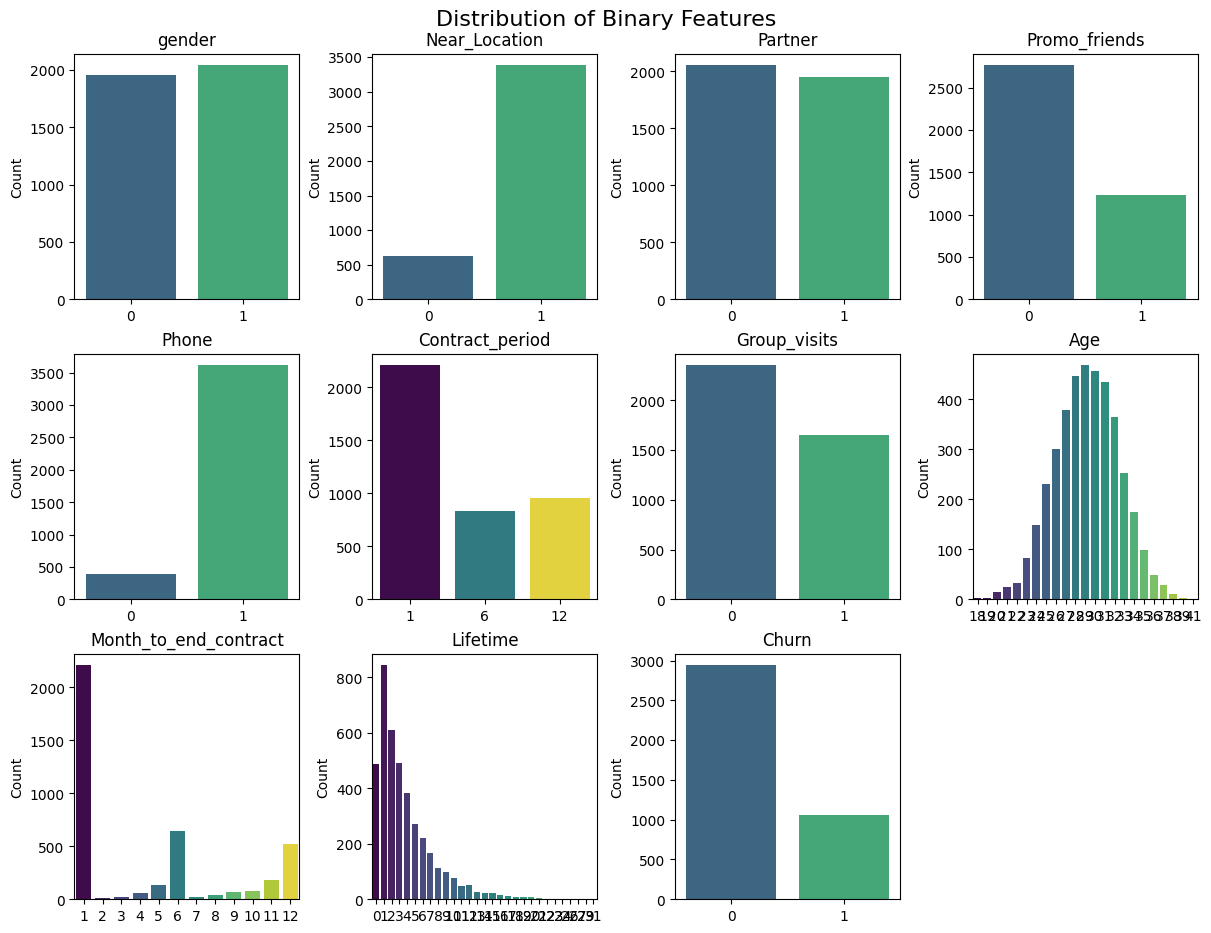

In [7]:
import seaborn as sns

int_cols = df.select_dtypes(include = 'int64').columns

num_plots = len(int_cols)
num_cols = 4
num_rows = (num_plots + num_cols - 2) // num_cols

fig, axes = plt.subplots(num_rows, num_cols,
                         figsize = (num_rows*4, num_rows*3),
                         constrained_layout = True)
axes = axes.flatten()

for i, col in enumerate(int_cols):
  sns.countplot(x = col, data = df, ax = axes[i],
                palette = 'viridis', hue = col, legend = False)
  axes[i].set_title(col)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Count')

for j in range(i+1, len(axes)):
  fig.delaxes(axes[j])

plt.suptitle('Distribution of Binary Features', y=1.02, fontsize=16)
plt.show()

####**Observe all of the numerical data type distributions**

/tmp/ipykernel_2849/1137336243.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = col, data = df, ax = axes[i], kde = True, palette = 'viridis')
/tmp/ipykernel_2849/1137336243.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = col, data = df, ax = axes[i], kde = True, palette = 'viridis')
/tmp/ipykernel_2849/1137336243.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = col, data = df, ax = axes[i], kde = True, palette = 'viridis')


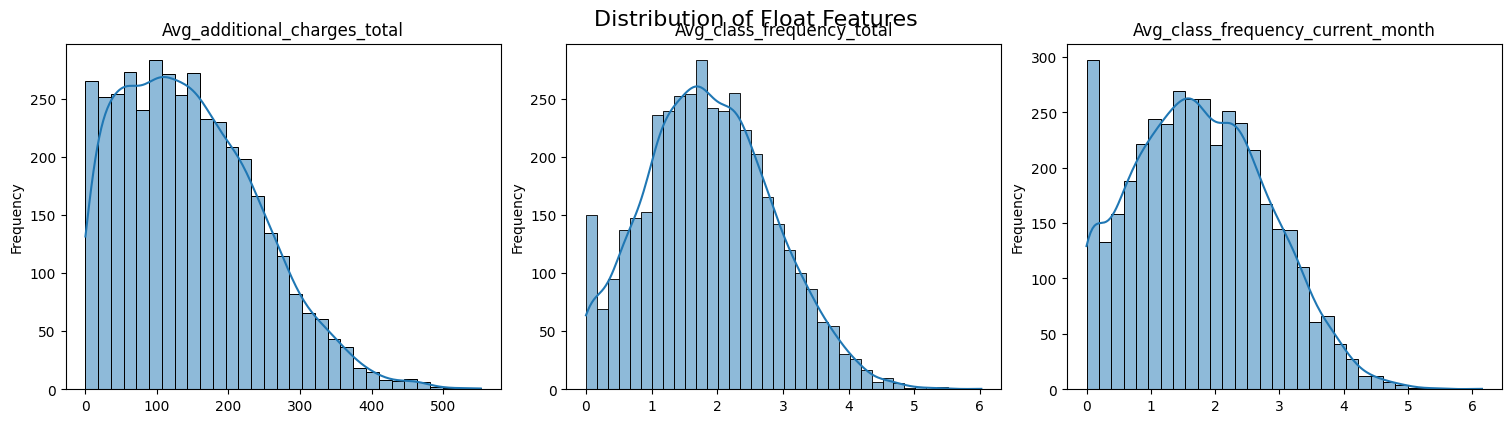

In [8]:
float_cols = df.select_dtypes(include = 'float64').columns

num_plots = len(float_cols)
num_cols = 3
# Calculate num_rows dynamically to ensure all plots are shown
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols,
                         figsize = (num_cols * 5, num_rows * 4),
                         constrained_layout = True)
axes = axes.flatten()

for i, col in enumerate(float_cols):
  # Use sns.histplot for continuous numerical data
  sns.histplot(x = col, data = df, ax = axes[i], kde = True, palette = 'viridis')
  axes[i].set_title(col)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Frequency') # Changed from Count to Frequency for histograms

# Remove any unused subplots
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.suptitle('Distribution of Float Features', y=1.02, fontsize=16)
plt.show()

####**Correlation Matrix of all features in the dataset with the `Churn` column**

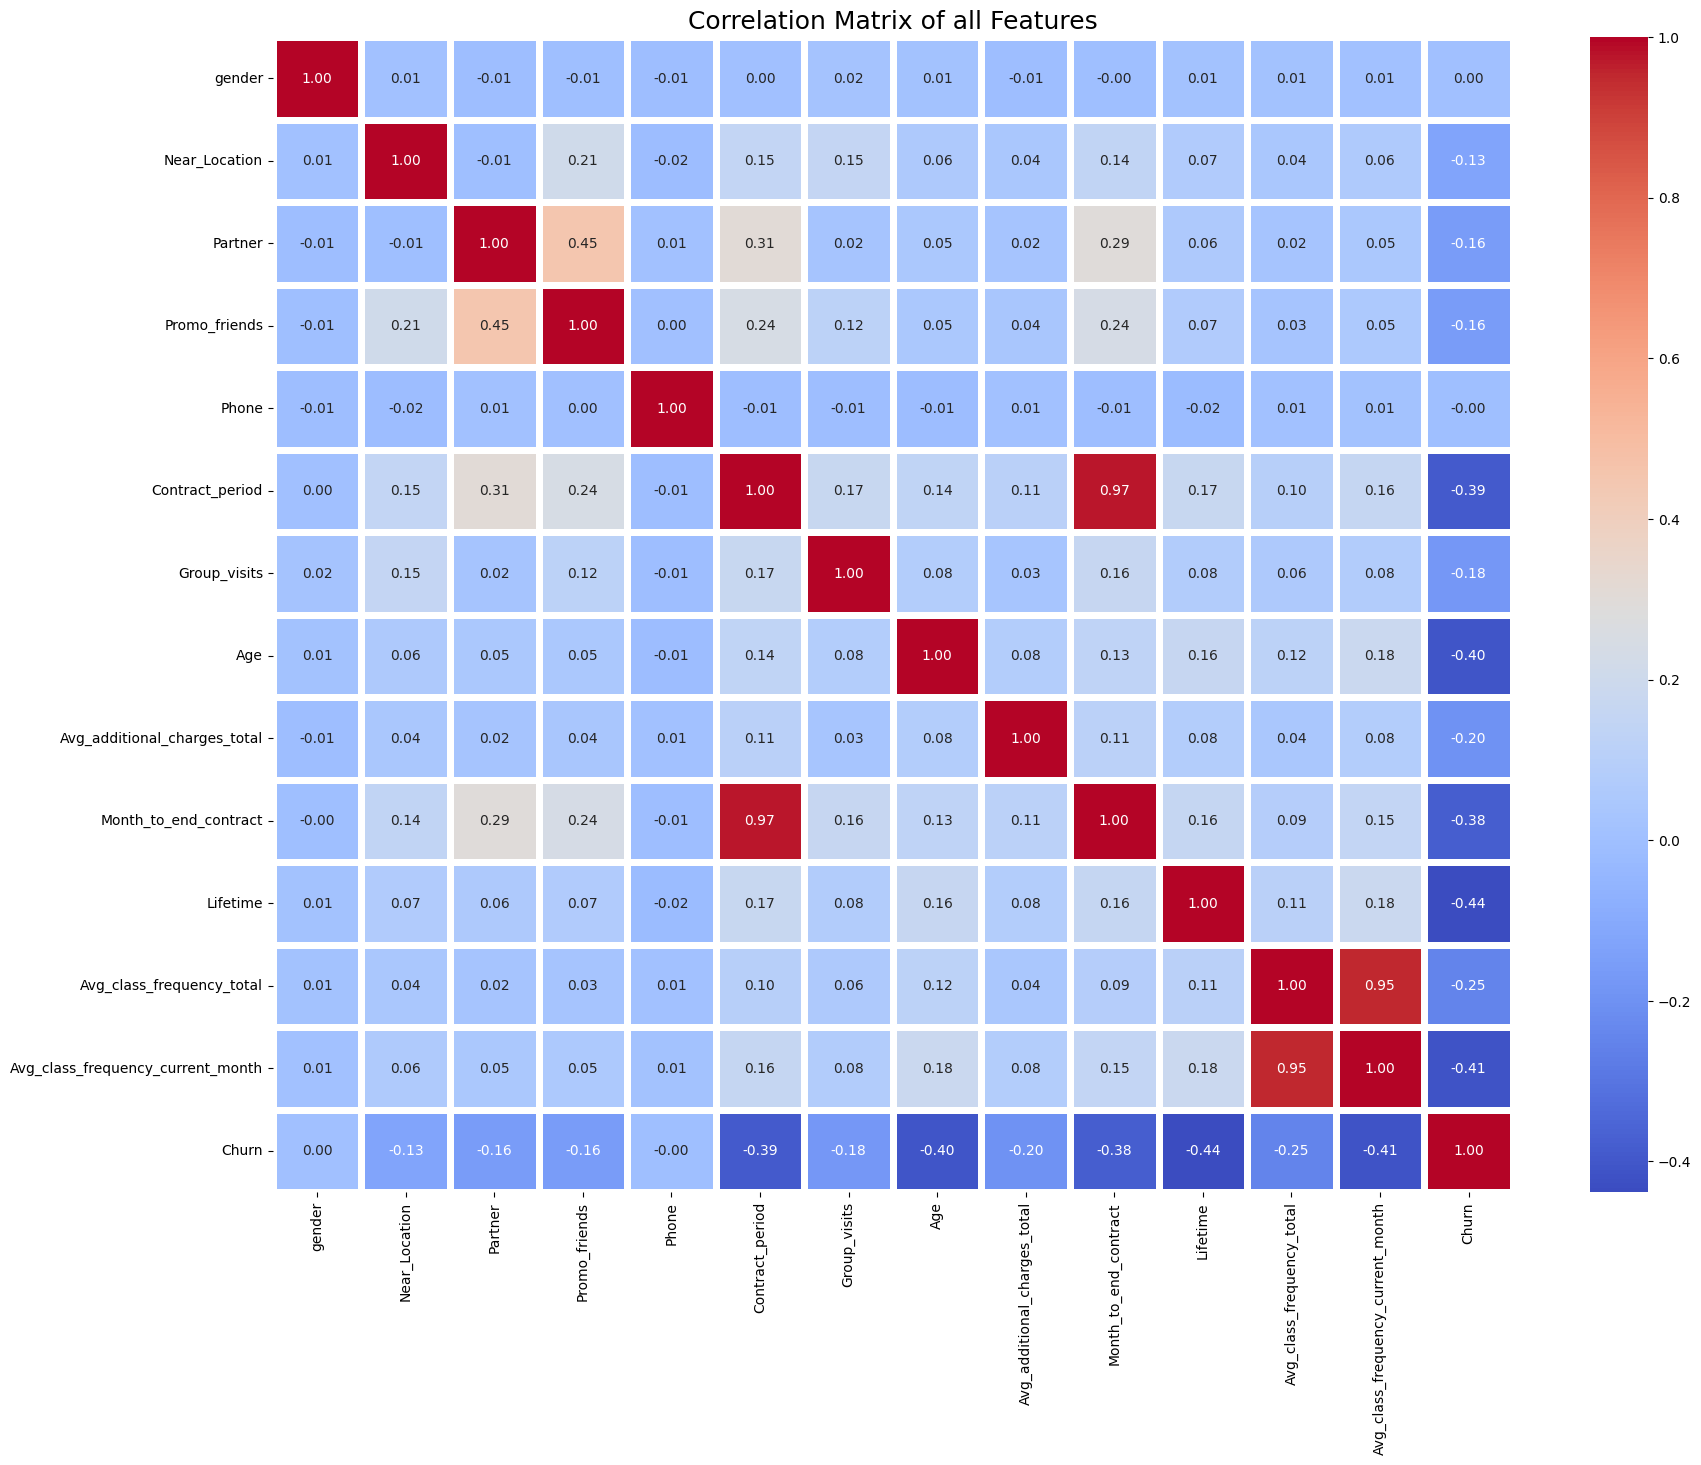

In [9]:
corr_matrix = df.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(data = corr_matrix,
            annot = True, cmap = 'coolwarm',
            fmt = ".2f",
            linewidths = 5)
plt.title('Correlation Matrix of all Features', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

**Results:** `Avg_class_frequency_current_month`, `Lifetime`, `Month_to_end_contract`, `Age`, and`Contract_period` are well inversely correlative with `Churn`.

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(['Churn'], axis = 1)
Y = df['Churn']


X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2,
    random_state= 123,
    stratify = Y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

print('\nChurn distribution in training set:')
print(Y_train.value_counts(normalize=True))
print('\nChurn distribution in test set:')
print(Y_test.value_counts(normalize=True))

X_train shape: (3200, 13)
X_test shape: (800, 13)
Y_train shape: (3200,)
Y_test shape: (800,)

Churn distribution in training set:
Churn
0    0.734688
1    0.265313
Name: proportion, dtype: float64

Churn distribution in test set:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


###**Preprocessing (Scaling)**

We'll use `StandardScaler` to transform our continuous numerical features. Integer features, which are already 0s and 1s, don't need additional scaling. We must scale the numerical datatypes into a standard normal distribution so that they are a) no longer skewed and b) no longer carry more weight for the magnitude of the values

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


numerical_cols = ['Avg_additional_charges_total',
                  'Avg_class_frequency_current_month',
                  'Avg_class_frequency_total']


#Create a preprocessor using columnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder = 'passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed. Shapes of processed data:")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

#Apply preprocessing to training and testing data


Preprocessing completed. Shapes of processed data:
X_train_processed shape: (3200, 13)
X_test_processed shape: (800, 13)


####**Model Training, Tuning, and Evaluation**

We'll now train a few different classification models, tune their hyperparameters using 5-fold cross-validation, and then evaluate their performance on the test set. Our focus will be on the 'Churn == Yes' or Churn == 1 class, so we'll pay close attention to metrics like recall and F1-score for this class, as well as the overall ROC AUC score.

#### Model: Gradient Boosting Classifier

In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

### Gradient Boosting Classifier Training and Hyperparameter Tuning

In [15]:
gb_model = GradientBoostingClassifier(random_state=123)

param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_search_gb = GridSearchCV(gb_model, param_grid_gb, cv=5, scoring='recall', n_jobs=-1, verbose=1)
grid_search_gb.fit(X_train_processed, Y_train)

print(f"Best parameters for Gradient Boosting: {grid_search_gb.best_params_}")
print(f"Best recall score for Gradient Boosting: {grid_search_gb.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best recall score for Gradient Boosting: 0.8693


### Gradient Boosting Classifier Evaluation

Gradient Boosting Classifier Metrics on Test Set:
  Recall: 0.8538
  Precision: 0.9282
  F1-Score: 0.8894
  ROC AUC Score: 0.9755


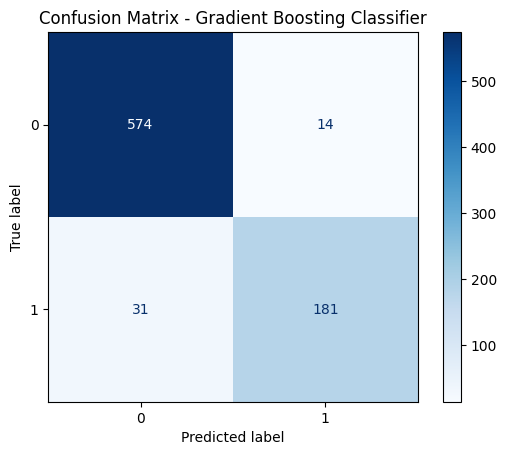

In [16]:
best_gb_model = grid_search_gb.best_estimator_
Y_pred_gb = best_gb_model.predict(X_test_processed)
Y_prob_gb = best_gb_model.predict_proba(X_test_processed)[:, 1]

recall_gb = recall_score(Y_test, Y_pred_gb)
precision_gb = precision_score(Y_test, Y_pred_gb)
f1_gb = f1_score(Y_test, Y_pred_gb)
roc_auc_gb = roc_auc_score(Y_test, Y_prob_gb)

print(f"Gradient Boosting Classifier Metrics on Test Set:")
print(f"  Recall: {recall_gb:.4f}")
print(f"  Precision: {precision_gb:.4f}")
print(f"  F1-Score: {f1_gb:.4f}")
print(f"  ROC AUC Score: {roc_auc_gb:.4f}")

# Confusion Matrix
cm_gb = confusion_matrix(Y_test, Y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=best_gb_model.classes_)
disp_gb.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.show()

**Results:** The Results are excellent.

- The recall of the model is 0.8538 which means out of all the customers that churned, 85% were predicted by the model to have correctly churned back.

- The precision of the model is 0.9282 which means out of all the customers that were predicted to have churned, 93% actually churned back.

- Both the PR-AUC and F1 score were satisfactory values which means that our Recall/Precision were balanced well.



Feature Importances:


,feature,importance
12,Avg_class_frequency_current_month,0.388879
2,Partner,0.175314
1,Near_Location,0.170640
11,Avg_class_frequency_total,0.095461
10,Lifetime,0.081323
0,gender,0.046292
8,Avg_additional_charges_total,0.028480
9,Month_to_end_contract,0.005631
6,Group_visits,0.002648
3,Promo_friends,0.001774


/tmp/ipykernel_2849/949750633.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


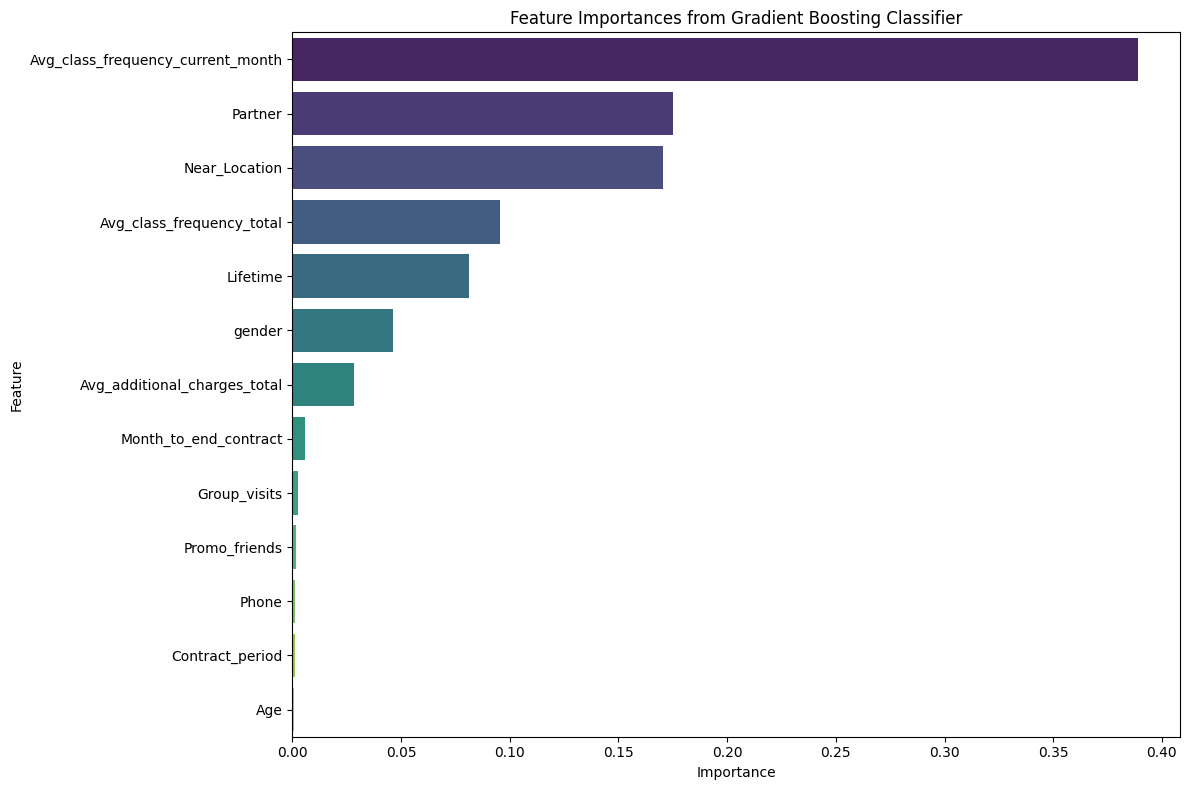

In [17]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_gb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importances:")
display(feature_importance)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Feature Importances from Gradient Boosting Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Results:** The features of highest importance:

- `Avg_class_frequency_current_month`
- `Partner`
- `Near_Location`
- `Avg_class_frequency_total`
- `Lifetime`

These five features were the greatest contributors to predicting who churned.

## Summary of Findings

This project aimed to predict customer churn for a gym using a Gradient Boosting Classifier. Through exploratory data analysis, we gained insights into the distribution and correlations of various features.

Key findings include:
- **Data Overview:** The dataset contained 4000 entries with 14 features, primarily numerical.
- **Feature Distributions:** We observed distinct distributions for different features, with some being binary (e.g., gender, Partner) and others continuous (e.g., Avg_additional_charges_total, Avg_class_frequency_current_month).
- **Correlation Analysis:** A correlation matrix highlighted features like `Avg_class_frequency_current_month`, `Lifetime`, `Month_to_end_contract`, `Age`, and `Contract_period` as having strong inverse correlations with `Churn`.
- **Model Performance:** The Gradient Boosting Classifier, after hyperparameter tuning focused on recall, achieved excellent performance on the test set:
    - **Recall:** 0.8538 (85% of actual churners were correctly identified).
    - **Precision:** 0.9282 (93% of predicted churners were actual churners).
    - **F1-Score:** 0.8894
    - **ROC AUC Score:** 0.9755
- **Feature Importance:** The most influential features for predicting churn were `Avg_class_frequency_current_month`, `Partner`, `Near_Location`, `Avg_class_frequency_total`, and `Lifetime`.

Overall, the model demonstrates a strong ability to identify customers at risk of churning, which can be valuable for targeted retention strategies.

## Future Work and Improvements

To further enhance this project and explore additional insights, the following steps could be considered:

1.  **Experiment with Other Models:** Evaluate other machine learning models such as Random Forest, XGBoost, or even deep learning approaches to see if they can achieve better or more robust performance.
2.  **Feature Engineering:** Create new features from existing ones (e.g., ratios, interactions) that might provide more predictive power. For instance, calculating average charges per month or frequency changes over time.
3.  **Anomaly Detection:** Investigate if there are any outliers or anomalous customer behaviors that might indicate early signs of churn.
4.  **Cost-Benefit Analysis:** Perform a cost-benefit analysis to determine the financial impact of different churn prediction and prevention strategies based on the model's output.
5.  **A/B Testing:** Design and implement A/B tests based on the model's predictions to validate retention strategies in a real-world scenario.
6.  **Interpretability:** Beyond feature importance, use explainable AI (XAI) techniques (e.g., SHAP, LIME) to understand individual predictions and model behavior more deeply.
7.  **Data Collection:** If possible, collect more granular data, such as customer feedback, engagement with specific gym services, or demographic information, to enrich the dataset.
8.  **Time Series Analysis:** If historical churn data for individual customers over time is available, explore time series models to predict churn, accounting for temporal patterns.